In [3]:
import os
import pickle

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

%matplotlib inline
import sys

from jax import config

config.update("jax_enable_x64", True)

os.getcwd()
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))


import desc

import yancc

# MDKE

In [11]:
def permutation_matrix(field, pitchgrid, axorder):
    x = np.arange(pitchgrid.na * field.ntheta * field.nzeta)
    x = yancc.smoothers.permute_f_3d(x, field, pitchgrid, axorder).flatten()
    P = scipy.sparse.eye_array(x.size, format="csr")[x, :]
    return P

In [12]:
def smoothing_factor(w, Ms, Ps, A, L):
    w = np.atleast_1d(w)
    l2out = []
    eigout = []
    Ks = [P @ M @ P.T @ A for M, P in zip(Ms, Ps)]
    I = scipy.sparse.eye_array(L.shape[0])
    for K in Ks:
        l2out1 = []
        eigout1 = []
        v = np.ones(L.shape[0])
        for wi in w:
            print(wi, end="\r")
            S = I - wi * K
            LS = L @ S
            fac = scipy.sparse.linalg.norm(LS) / scipy.sparse.linalg.norm(L)
            l2out1.append(fac)
            try:
                e, v = scipy.sparse.linalg.eigs(
                    S, k=1, v0=v, maxiter=1000, tol=1e-3, which="LM"
                )
            except scipy.sparse.linalg.ArpackNoConvergence:
                e = np.array(np.nan)
            eigout1.append(abs(e).max())
        l2out.append(l2out1)
        eigout.append(eigout1)
    return np.array(l2out).T, np.array(eigout).T

In [13]:
import yancc.smoothers
import yancc.trajectories_scipy


def get_smoothers_for_factor(field, pitchgrid, E_psi, nu, p1, p2):
    Ds = [
        yancc.trajectories.MDKE(
            field, pitchgrid, E_psi, nu, p1=p1, p2=p2, axorder=axorder, gauge=True
        ).block_diagonal()
        for axorder in ["atz", "zat", "tza"]
    ]
    Dis = [np.linalg.inv(D) for D in Ds]
    Mi_jac = [scipy.sparse.block_diag(D) for D in Dis]
    Ps = [
        permutation_matrix(field, pitchgrid, axorder)
        for axorder in ["atz", "zat", "tza"]
    ]
    A = yancc.trajectories_scipy.mdke(field, pitchgrid, E_psi, nu, p1, p2, True)
    L = scipy.sparse.linalg.LaplacianNd(
        (pitchgrid.na, field.ntheta, field.nzeta), boundary_conditions="periodic"
    ).tosparse()
    return Mi_jac, Ps, A, L

In [32]:
def plot_smoothing_data(data):
    unique_nu = np.unique(data["nus"])

    fig = matplotlib.figure.Figure(figsize=(16, 8))
    ax = fig.subplots(len(unique_nu), 6, sharex=True)

    for k, nu in enumerate(unique_nu):
        ax[k, 0].set_ylabel(f"nu={nu:.1e}")
        for i in range(3):
            ax[k, i].plot(
                data["w"],
                data["smoothing_factors"][np.where(data["nus"] == nu)[0], :, i].T,
            )
            ax[k, i].grid(True)
            ax[k, i].set_ylim(0, 1)
            ax[k, i + 3].plot(
                data["w"],
                data["eigenvalues"][np.where(data["nus"] == nu)[0], :, i].T,
            )
            ax[k, i + 3].grid(True)

    ax[0, 0].set_title("smooth atz (zeta)")
    ax[0, 1].set_title("smooth zat (theta)")
    ax[0, 2].set_title("smooth tza (xi)")
    ax[0, 3].set_title("eig atz (zeta)")
    ax[0, 4].set_title("eig zat (theta)")
    ax[0, 5].set_title("eig tza (xi)")
    return fig

In [6]:
eq_names = ["W7-X", "NCSX", "HSX", "HELIOTRON"]
nuhats = [1e-6, 1e-4, 1e-2, 1e-0, 1e2]
Ehats = [0.0, 1e-4, 1e-2, 1e-0]
resolutions = [(65, 33, 17), (33, 17, 9)]  # nxi, nzeta, ntheta

fields = []
pitchgrids = []
E_psis = []
nus = []
hyperparam_names = []


for name in eq_names:
    eq = desc.examples.get(name)
    for nuhat in nuhats:
        for Ehat in Ehats:
            for res in resolutions:
                nxi, nz, nt = res
                fields.append(yancc.field.Field.from_desc(eq, 0.5, nt, nz))
                pitchgrids.append(yancc.velocity_grids.UniformPitchAngleGrid(nxi))
                E_psis.append(Ehat)
                nus.append(nuhat)
                hyper_name = name + f" res={res}, E={Ehat:.3e}, nu={nuhat:.3e}"
                print(hyper_name)
                hyperparam_names.append(hyper_name)

W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-06
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e-02, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e-02, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e+00, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e+00, nu=1.000e-06
W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-04
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e-02, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e-02, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e+00, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e+00, nu=1.000e-04
W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-02
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-02
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-02
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-02
W7-X res=(65, 33, 17), E=1.000

# 2a2

In [27]:
p1 = "2a"
p2 = 2

Ms = []
Ps = []
As = []
Ls = []

for field, grid, E_psi, nu, name in zip(
    fields, pitchgrids, E_psis, nus, hyperparam_names
):
    M, P, A, L = get_smoothers_for_factor(field, grid, E_psi, nu, p1, p2)
    Ms.append(M)
    Ps.append(P)
    As.append(A)
    Ls.append(L)
    print(name)

W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-06
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e-02, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e-02, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e+00, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e+00, nu=1.000e-06
W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-04
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e-02, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e-02, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e+00, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e+00, nu=1.000e-04
W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-02
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-02
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-02
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-02
W7-X res=(65, 33, 17), E=1.000

In [ ]:
w = np.linspace(0, 1, 20)[1:]

allout = []
eigout = []
for M, P, A, L, name in zip(Ms, Ps, As, Ls, hyperparam_names):
    t, e = smoothing_factor(w, M, P, A, L)
    allout.append(t)
    eigout.append(e)
    print(name)
allout = np.array(allout)
eigout = np.array(eigout)

data = {
    "smoothing_factors": allout,
    "eigenvalues": eigout,
    "hyperparam_names": hyperparam_names,
    "nus": np.array(nus),
    "E_psis": np.array(E_psis),
    "w": np.array(w),
}


with open(f"data_{p1}{p2}.pkl", "wb+") as f:
    pickle.dump(data, f)

W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-06
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e-02, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e-02, nu=1.000e-06
W7-X res=(65, 33, 17), E=1.000e+00, nu=1.000e-06
W7-X res=(33, 17, 9), E=1.000e+00, nu=1.000e-06
W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-04
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e-02, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e-02, nu=1.000e-04
W7-X res=(65, 33, 17), E=1.000e+00, nu=1.000e-04
W7-X res=(33, 17, 9), E=1.000e+00, nu=1.000e-04
W7-X res=(65, 33, 17), E=0.000e+00, nu=1.000e-02
W7-X res=(33, 17, 9), E=0.000e+00, nu=1.000e-02
W7-X res=(65, 33, 17), E=1.000e-04, nu=1.000e-02
W7-X res=(33, 17, 9), E=1.000e-04, nu=1.000e-02
0.89473684210526376

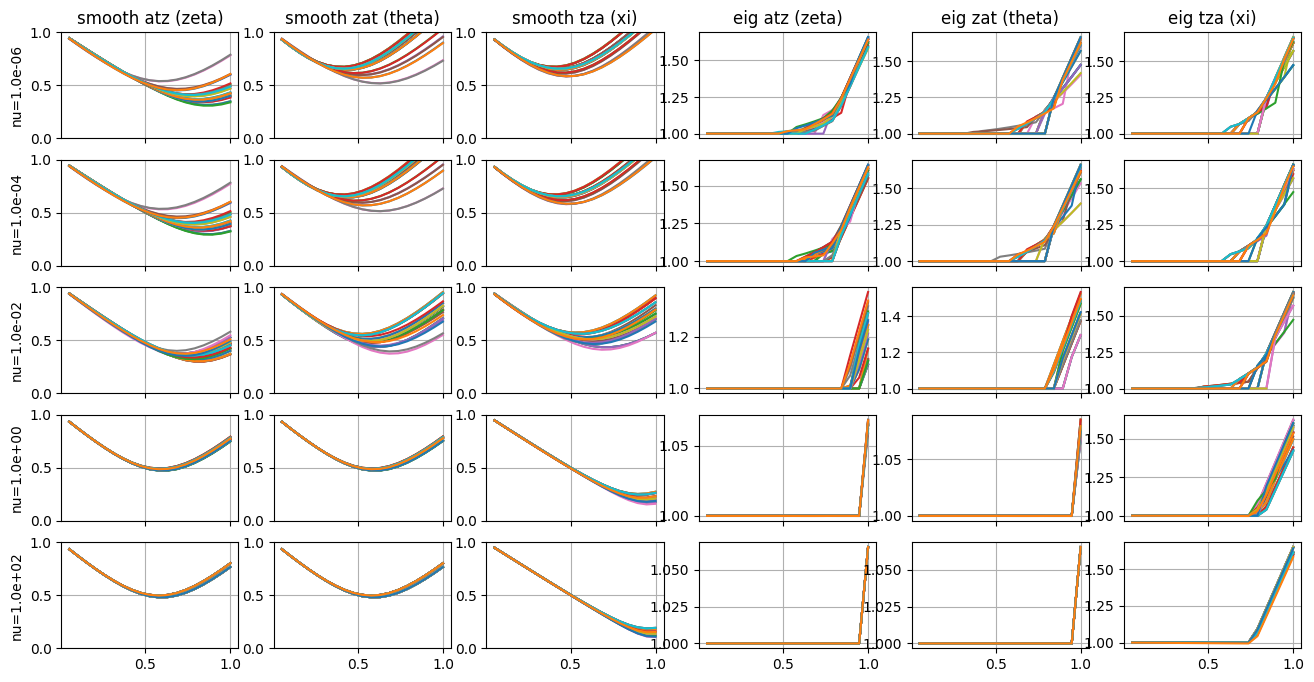

In [35]:
with open("data_2a2.pkl", "rb") as f:
    data = pickle.load(f)
plot_smoothing_data(data)

# 2b2

In [ ]:
p1 = "2b"
p2 = 2

Ms = []
Ps = []
As = []
Ls = []

for field, grid, E_psi, nu, name in zip(
    fields, pitchgrids, E_psis, nus, hyperparam_names
):
    M, P, A, L = get_smoothers_for_factor(field, grid, E_psi, nu, p1, p2)
    Ms.append(M)
    Ps.append(P)
    As.append(A)
    Ls.append(L)
    print(name)

In [ ]:
w = np.linspace(0, 1, 20)[1:]

allout = []
eigout = []
for M, P, A, L, name in zip(Ms, Ps, As, Ls, hyperparam_names):
    t, e = smoothing_factor(w, M, P, A, L)
    allout.append(t)
    eigout.append(e)
    print(name)
allout = np.array(allout)
eigout = np.array(eigout)

data = {
    "smoothing_factors": allout,
    "eigenvalues": eigout,
    "hyperparam_names": hyperparam_names,
    "nus": np.array(nus),
    "E_psis": np.array(E_psis),
    "w": np.array(w),
}

import pickle

with open(f"data_{p1}{p2}.pkl", "wb+") as f:
    pickle.dump(data, f)

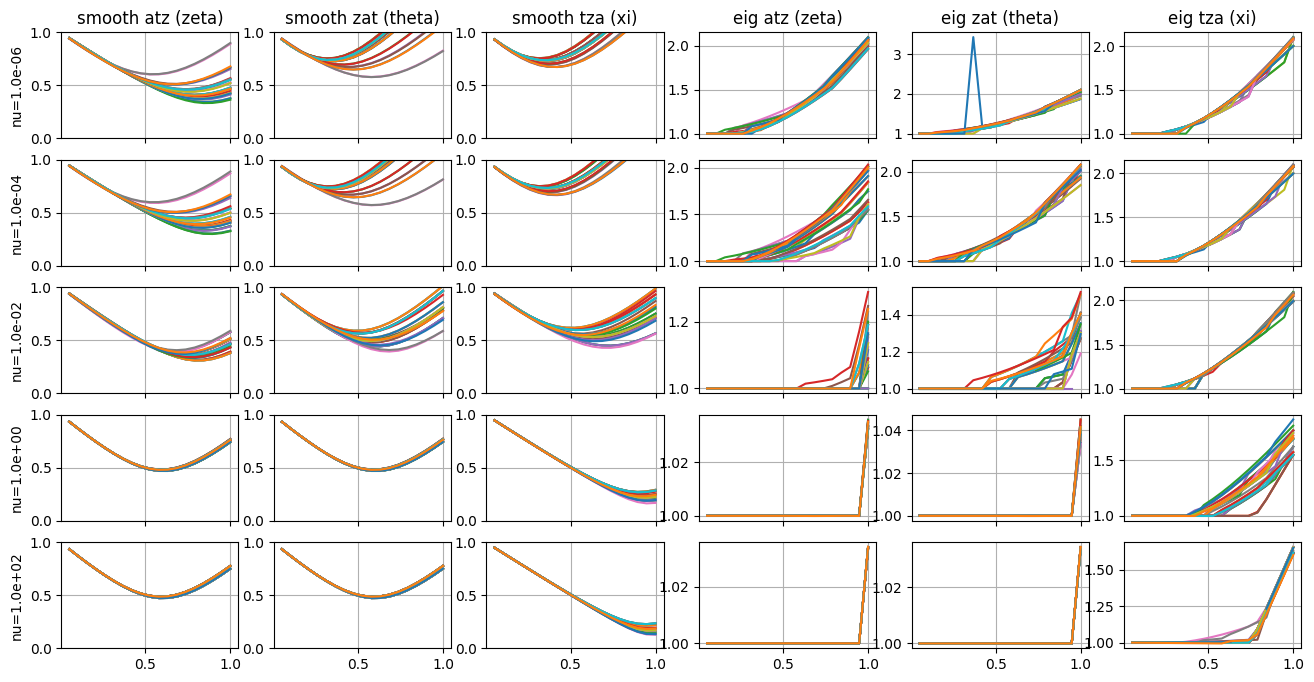

In [36]:
with open("data_2b2.pkl", "rb") as f:
    data = pickle.load(f)
plot_smoothing_data(data)

# 2c2

In [ ]:
p1 = "2c"
p2 = 2

Ms = []
Ps = []
As = []
Ls = []

for field, grid, E_psi, nu, name in zip(
    fields, pitchgrids, E_psis, nus, hyperparam_names
):
    M, P, A, L = get_smoothers_for_factor(field, grid, E_psi, nu, p1, p2)
    Ms.append(M)
    Ps.append(P)
    As.append(A)
    Ls.append(L)
    print(name)

In [ ]:
w = np.linspace(0, 1, 20)[1:]

allout = []
eigout = []
for M, P, A, L, name in zip(Ms, Ps, As, Ls, hyperparam_names):
    t, e = smoothing_factor(w, M, P, A, L)
    allout.append(t)
    eigout.append(e)
    print(name)
allout = np.array(allout)
eigout = np.array(eigout)

data = {
    "smoothing_factors": allout,
    "eigenvalues": eigout,
    "hyperparam_names": hyperparam_names,
    "nus": np.array(nus),
    "E_psis": np.array(E_psis),
    "w": np.array(w),
}

import pickle

with open(f"data_{p1}{p2}.pkl", "wb+") as f:
    pickle.dump(data, f)

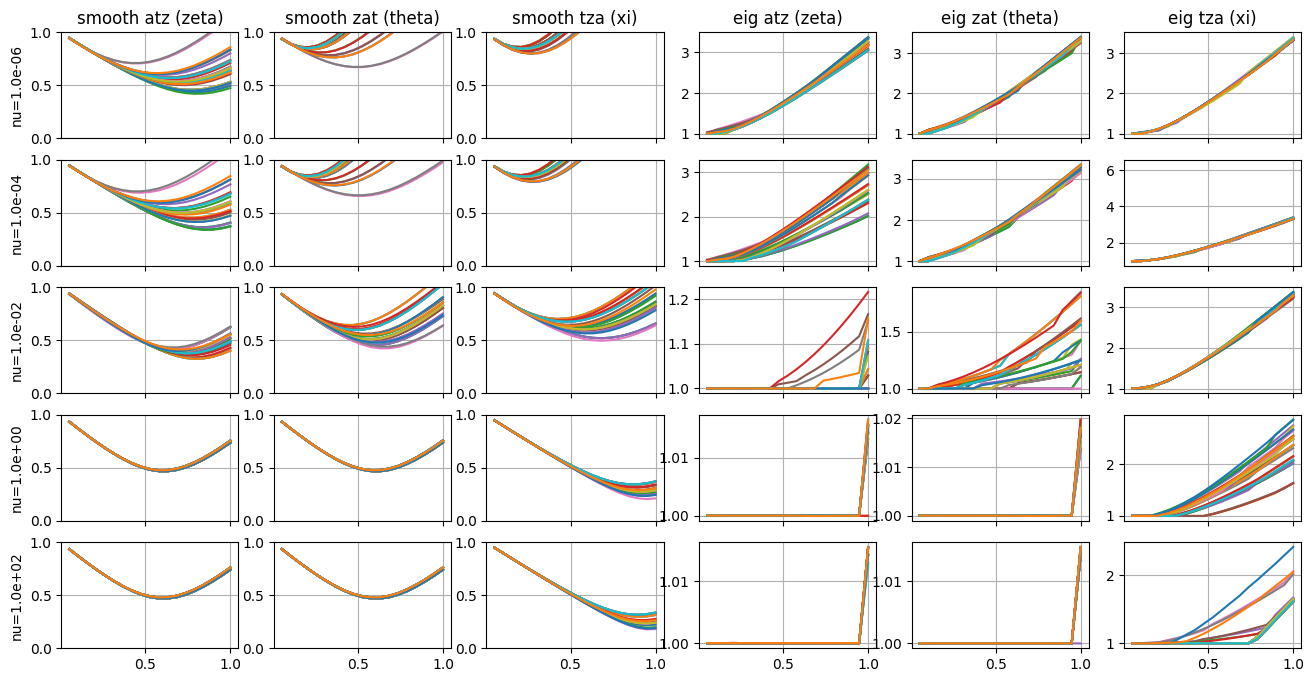

In [37]:
with open("data_2c2.pkl", "rb") as f:
    data = pickle.load(f)
plot_smoothing_data(data)

# 2d2

In [ ]:
p1 = "2d"
p2 = 2

Ms = []
Ps = []
As = []
Ls = []

for field, grid, E_psi, nu, name in zip(
    fields, pitchgrids, E_psis, nus, hyperparam_names
):
    M, P, A, L = get_smoothers_for_factor(field, grid, E_psi, nu, p1, p2)
    Ms.append(M)
    Ps.append(P)
    As.append(A)
    Ls.append(L)
    print(name)

In [ ]:
w = np.linspace(0, 1, 20)[1:]

allout = []
eigout = []
for M, P, A, L, name in zip(Ms, Ps, As, Ls, hyperparam_names):
    t, e = smoothing_factor(w, M, P, A, L)
    allout.append(t)
    eigout.append(e)
    print(name)
allout = np.array(allout)
eigout = np.array(eigout)

data = {
    "smoothing_factors": allout,
    "eigenvalues": eigout,
    "hyperparam_names": hyperparam_names,
    "nus": np.array(nus),
    "E_psis": np.array(E_psis),
    "w": np.array(w),
}

import pickle

with open(f"data_{p1}{p2}.pkl", "wb+") as f:
    pickle.dump(data, f)

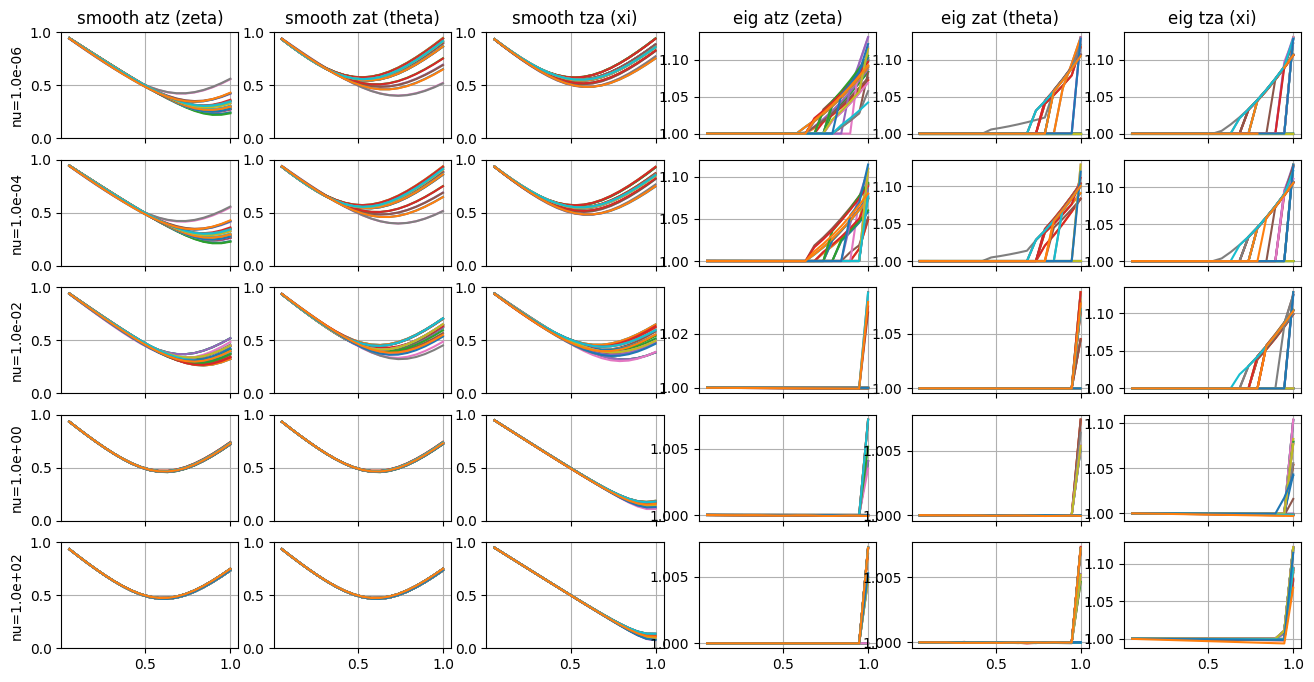

In [38]:
with open("data_2d2.pkl", "rb") as f:
    data = pickle.load(f)
plot_smoothing_data(data)

# optimal $\omega$ for different fd methods

In [4]:
methods = [
    "2c2",
    "2d2",
]
alldata = {}
for method in methods:
    with open("data_" + method + ".pkl", "rb") as f:
        alldata[method] = pickle.load(f)

for method in methods:
    data = alldata[method]
    unique_nu = np.unique(data["nus"])
    best_ws = []
    best_ss = []
    for nu in unique_nu:
        nudata = data["smoothing_factors"][np.where(data["nus"] == nu)[0]]
        eigval = data["eigenvalues"][np.where(data["nus"] == nu)[0]]
        eigval = np.nan_to_num(eigval, nan=10)
        nudata = nudata.max(axis=0)  # max over configurations etc
        eigval = eigval.max(axis=0)
        # don't want smoothers that blow up
        nudata_temp = np.where(eigval > 1.01, np.inf, nudata)
        best_idx = np.argmin(nudata_temp, axis=0)
        best_w = data["w"][best_idx]
        best_s = np.diag(nudata[best_idx])
        best_ws.append(best_w)
        best_ss.append(best_s)
    data["best_ws"] = np.array(best_ws)
    data["best_ss"] = np.array(best_ss)
    data["unique_nu"] = unique_nu

In [12]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

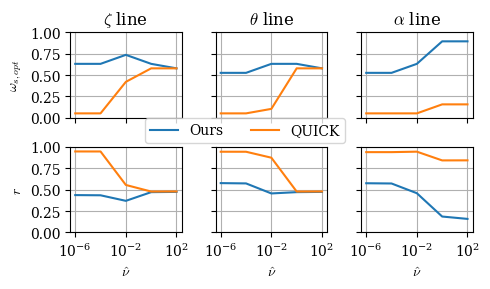

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(5, 3), sharex=True, sharey="row")
labels = ["Ours", "QUICK"]
for j, (method, label) in enumerate(zip(methods[::-1], labels)):
    data = alldata[method]
    for i in range(3):
        if i != 0:
            label = None
        ax[0, i].semilogx(data["unique_nu"], data["best_ws"][:, i], label=label)
        ax[1, i].semilogx(data["unique_nu"], data["best_ss"][:, i])
        ax[0, i].set_ylim(0, 1)
        ax[1, i].set_ylim(0, 1)
        # ax[i, 0].set_yticks(np.linspace(0, 1, 6))
        # ax[i, 1].set_yticks(np.linspace(0, 1, 6))
        ax[0, i].grid(True)
        ax[1, i].grid(True)
for i in range(3):
    ax[1, i].set_xticks(data["unique_nu"][::2])
    ax[1, i].set_xlabel("$\\hat{\\nu}$")
    ax[1, i].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[0, i].set_yticks([0, 0.25, 0.5, 0.75, 1.0])

ax[0, 0].set_ylabel("$\\omega_{s,opt}$")
ax[1, 0].set_ylabel("$r$")
ax[0, 0].set_title("$\\zeta$ line")
ax[0, 1].set_title("$\\theta$ line")
ax[0, 2].set_title("$\\alpha$ line")
# ax[0,0].legend()
fig.legend(loc="lower center", ncols=2, bbox_to_anchor=(0.5, 0.48))

fig.set_tight_layout(True)

In [14]:
fig.savefig("smoothing.png")
fig.savefig("smoothing.pdf")